<a href="https://colab.research.google.com/github/R267/Marchenko-lab6/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
primaryobjects_voicegender_path = kagglehub.dataset_download('primaryobjects/voicegender')

print('Data source import complete.')


Data source import complete.


Here I m going to run **Support Vector machine** with different **kernels(linear,gaussian,polynomial)** and also tune the various parameters such as **C** ,**gamma** and **degree** to find out the best performing model .

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in


# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

from subprocess import check_output
print(check_output(["ls", "/content/voice.csv"]).decode("utf8"))

# Any results you write to the current directory are saved as output.

/content/voice.csv



# Importing all the necessary libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

%matplotlib inline

# Reading the comma separated values file into the dataframe

In [5]:
df = pd.read_csv('/content/voice.csv')
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


# Checking the correlation between each feature

In [7]:
df_numeric = df.select_dtypes(include='number')
correlation_matrix = df_numeric.corr()
print(correlation_matrix)


          meanfreq        sd    median       Q25       Q75       IQR  \
meanfreq  1.000000 -0.739039  0.925445  0.911416  0.740997 -0.627605   
sd       -0.739039  1.000000 -0.562603 -0.846931 -0.161076  0.874660   
median    0.925445 -0.562603  1.000000  0.774922  0.731849 -0.477352   
Q25       0.911416 -0.846931  0.774922  1.000000  0.477140 -0.874189   
Q75       0.740997 -0.161076  0.731849  0.477140  1.000000  0.009636   
IQR      -0.627605  0.874660 -0.477352 -0.874189  0.009636  1.000000   
skew     -0.322327  0.314597 -0.257407 -0.319475 -0.206339  0.249497   
kurt     -0.316036  0.346241 -0.243382 -0.350182 -0.148881  0.316185   
sp.ent   -0.601203  0.716620 -0.502005 -0.648126 -0.174905  0.640813   
sfm      -0.784332  0.838086 -0.661690 -0.766875 -0.378198  0.663601   
mode      0.687715 -0.529150  0.677433  0.591277  0.486857 -0.403764   
centroid  1.000000 -0.739039  0.925445  0.911416  0.740997 -0.627605   
meanfun   0.460844 -0.466281  0.414909  0.545035  0.155091 -0.53

# Checking whether there is any null values

In [8]:
df.isnull().sum()

,0
meanfreq,0
sd,0
median,0
Q25,0
Q75,0
IQR,0
skew,0
kurt,0
sp.ent,0
sfm,0


In [9]:
df.shape

(3168, 21)

In [10]:
print("Total number of labels: {}".format(df.shape[0]))
print("Number of male: {}".format(df[df.label == 'male'].shape[0]))
print("Number of female: {}".format(df[df.label == 'female'].shape[0]))

Total number of labels: 3168
Number of male: 1584
Number of female: 1584


Thus we can see there are equal number of male and female labels

In [11]:
df.shape

(3168, 21)

There are 21 features and 3168 instances.

# Separating features and labels

In [12]:
X=df.iloc[:, :-1]
X.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,0.000000,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,0.000000,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,0.000000,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,0.083878,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,0.104261,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274


# Converting string value to int type for labels

In [13]:
from sklearn.preprocessing import LabelEncoder
y=df.iloc[:,-1]

# Encode label category
# male -> 1
# female -> 0

gender_encoder = LabelEncoder()
y = gender_encoder.fit_transform(y)
y

array([1, 1, 1, ..., 0, 0, 0])

# Data Standardisation
Standardization refers to shifting the distribution of each attribute to have a mean of zero and a standard deviation of one (unit variance). It is useful to standardize attributes for a model. Standardization of datasets is a common requirement for many machine learning estimators implemented in scikit-learn; they might behave badly if the individual features do not more or less look like standard normally distributed data.

In [ ]:
# Scale the data to be between -1 and 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

# Splitting dataset into training set and testing set for better generalisation

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Running SVM with default hyperparameter.

In [15]:
from sklearn.svm import SVC
from sklearn import metrics
svc=SVC() #Default hyperparameters
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.6829652996845426


# Default Linear kernel

In [16]:
svc=SVC(kernel='linear')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.9148264984227129


# Default RBF kernel

In [17]:
svc=SVC(kernel='rbf')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.6829652996845426


We can conclude from above that svm by default uses **rbf** kernel as a parameter for kernel

# Default Polynomial kernel

In [18]:
svc=SVC(kernel='poly')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.5031545741324921


Polynomial kernel is performing poorly.The reason behind this maybe it is overfitting the training dataset

# Performing K-fold cross validation with different kernels

# CV on Linear kernel

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

svc = SVC(kernel='linear')
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')  # cv is cross-validation
print(scores)


[0.72239748 0.94321767 0.84542587 0.96214511 0.94006309 0.99684543
 0.97791798 0.96845426 0.9335443  0.90189873]


We can see above how the accuracy score is different everytime.This shows that accuracy score depends upon how the datasets got split.

In [21]:
print(scores.mean())

0.9191909914946292


In K-fold cross validation we generally take the mean of all the scores.

# CV on rbf kernel

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

svc = SVC(kernel='rbf')
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
print(scores)


[0.51104101 0.5488959  0.63722397 0.69716088 0.73501577 0.76971609
 0.75394322 0.67192429 0.61075949 0.65189873]


In [24]:
print(scores.mean())

0.658757936349479


# CV on Polynomial kernel

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

svc = SVC(kernel='poly')
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
print(scores)


[0.58044164 0.53943218 0.45425868 0.5615142  0.50157729 0.50157729
 0.50157729 0.50157729 0.48417722 0.50316456]


In [29]:
print(scores.mean())

0.5129297608114044


**When K-fold cross validation is done we can see different score in each iteration.This happens because when we use train_test_split method,the dataset get split in random manner into testing and training dataset.Thus it depends on how the dataset got split and which samples are training set and which samples are in testing set.**

**With K-fold cross validation we can see that the dataset got split into 10 equal parts thus covering all the data into training as well into testing set.This is the reason we got 10 different accuracy score.**

### Taking all the values of C and checking out the accuracy score with kernel as linear.

**The C parameter tells the SVM optimization how much you want to avoid misclassifying each training example. For large values of C, the optimization will choose a smaller-margin hyperplane if that hyperplane does a better job of getting all the training points classified correctly. Conversely, a very small value of C will cause the optimizer to look for a larger-margin separating hyperplane, even if that hyperplane misclassifies more points.**

**Thus for a very large values we can cause overfitting of the model and for a very small value of C we can cause underfitting.Thus the value of C must be chosen in such a manner that it generalised the unseen data well**

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# Load example data
data = load_iris()
X = data.data
y = data.target

# Cross-validation with varying C
C_range = list(range(1, 26))
acc_score = []

for c in C_range:
    svc = SVC(kernel='linear', C=c)
    scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
    acc_score.append(scores.mean())

print(acc_score)




[np.float64(0.9733333333333334), np.float64(0.9800000000000001), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9666666666666668), np.float64(0.9666666666666668), np.float64(0.9666666666666668), np.float64(0.9666666666666668), np.float64(0.9666666666666668), np.float64(0.9666666666666668), np.float64(0.9666666666666668)]


Text(0, 0.5, 'Cross-Validated Accuracy')

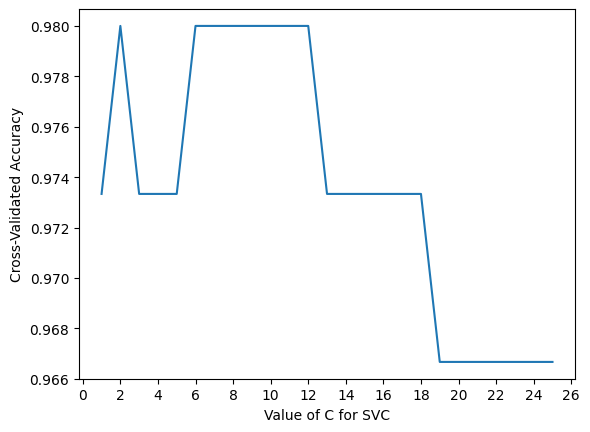

In [9]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


C_values=list(range(1,26))
# plot the value of C for SVM (x-axis) versus the cross-validated accuracy (y-axis)
plt.plot(C_values,acc_score)
plt.xticks(np.arange(0,27,2))
plt.xlabel('Value of C for SVC')
plt.ylabel('Cross-Validated Accuracy')

**From the above plot we can see that accuracy has been close to 97% for C=1 and C=6 and then it drops around 96.8% and remains constant.**

### Let us look into more detail of what is the exact value of C which is giving us a good accuracy score

In [10]:
C_range=list(np.arange(0.1,6,0.1))
acc_score=[]
for c in C_range:
    svc = SVC(kernel='linear', C=c)
    scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)


[np.float64(0.9733333333333334), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9866666666666667), np.float64(0.9866666666666667), np.float64(0.9800000000000001), np.float64(0.9866666666666667), np.float64(0.9866666666666667), np.float64(0.9800000000000001), np.float64(0.9733333333333334), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9866666666666667), np.float64(0.9866666666666667), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9800000000000001), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.floa

Text(0, 0.5, 'Cross-Validated Accuracy')

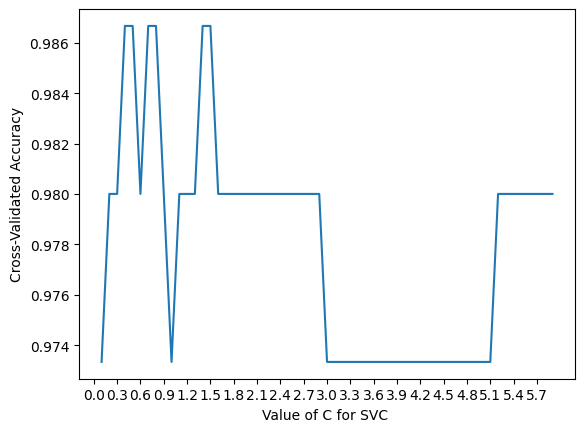

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

C_values=list(np.arange(0.1,6,0.1))
# plot the value of C for SVM (x-axis) versus the cross-validated accuracy (y-axis)
plt.plot(C_values,acc_score)
plt.xticks(np.arange(0.0,6,0.3))
plt.xlabel('Value of C for SVC ')
plt.ylabel('Cross-Validated Accuracy')

### Accuracy score is highest for C=0.1.

### Taking kernel as **rbf** and taking different values gamma

**Technically, the gamma parameter is the inverse of the standard deviation of the RBF kernel (Gaussian function), which is used as similarity measure between two points. Intuitively, a small gamma value define a Gaussian function with a large variance. In this case, two points can be considered similar even if are far from each other. In the other hand, a large gamma value means define a Gaussian function with a small variance and in this case, two points are considered similar just if they are close to each other**

In [12]:
gamma_range=[0.0001,0.001,0.01,0.1,1,10,100]
acc_score=[]
for g in gamma_range:
    svc = SVC(kernel='rbf', gamma=g)
    scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)


[np.float64(0.9066666666666666), np.float64(0.9066666666666666), np.float64(0.9400000000000001), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9333333333333333), np.float64(0.6133333333333334)]


Text(0, 0.5, 'Cross-Validated Accuracy')

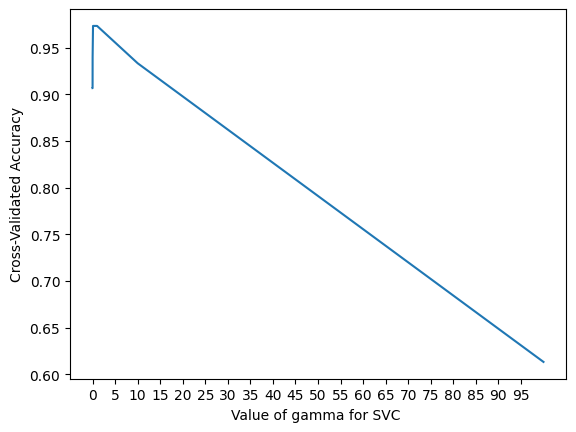

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

gamma_range=[0.0001,0.001,0.01,0.1,1,10,100]

# plot the value of C for SVM (x-axis) versus the cross-validated accuracy (y-axis)
plt.plot(gamma_range,acc_score)
plt.xlabel('Value of gamma for SVC ')
plt.xticks(np.arange(0.0001,100,5))
plt.ylabel('Cross-Validated Accuracy')

**We can see that for gamma=10 and 100 the kernel is performing poorly.We can also see a slight dip in accuracy score when gamma is 1.Let us look into more details for the range 0.0001 to 0.1.**

In [14]:
gamma_range=[0.0001,0.001,0.01,0.1]
acc_score=[]
for g in gamma_range:
    svc = SVC(kernel='rbf', gamma=g)
    scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)


[np.float64(0.9066666666666666), np.float64(0.9066666666666666), np.float64(0.9400000000000001), np.float64(0.9733333333333334)]


Text(0, 0.5, 'Cross-Validated Accuracy')

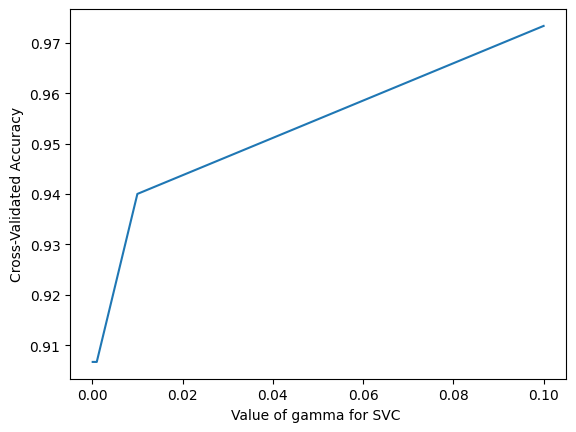

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

gamma_range=[0.0001,0.001,0.01,0.1]

# plot the value of C for SVM (x-axis) versus the cross-validated accuracy (y-axis)
plt.plot(gamma_range,acc_score)
plt.xlabel('Value of gamma for SVC ')
plt.ylabel('Cross-Validated Accuracy')

The score increases steadily and raches its peak at 0.01 and then decreases till gamma=1.Thus Gamma should be around 0.01.

Let us look into more detail for gamma values

In [16]:
gamma_range=[0.01,0.02,0.03,0.04,0.05]
acc_score=[]
for g in gamma_range:
    svc = SVC(kernel='rbf', gamma=g)
    scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)


[np.float64(0.9400000000000001), np.float64(0.9533333333333334), np.float64(0.96), np.float64(0.9733333333333334), np.float64(0.9800000000000001)]


Text(0, 0.5, 'Cross-Validated Accuracy')

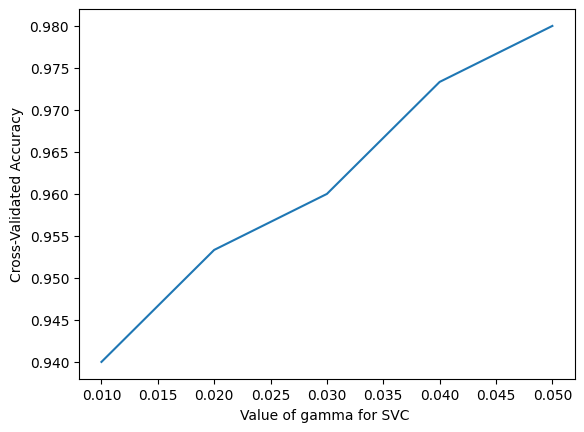

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

gamma_range=[0.01,0.02,0.03,0.04,0.05]

# plot the value of C for SVM (x-axis) versus the cross-validated accuracy (y-axis)
plt.plot(gamma_range,acc_score)
plt.xlabel('Value of gamma for SVC ')
plt.ylabel('Cross-Validated Accuracy')

**We can see there is constant decrease in the accuracy score as gamma value increase.Thus gamma=0.01 is the best parameter.**

# Taking polynomial kernel with different degree

In [18]:
degree=[2,3,4,5,6]
acc_score=[]
for d in degree:
    svc = SVC(kernel='poly', degree=d)
    scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)


[np.float64(0.9733333333333334), np.float64(0.9666666666666668), np.float64(0.9800000000000001), np.float64(0.9733333333333334), np.float64(0.96)]


Text(0, 0.5, 'Cross-Validated Accuracy')

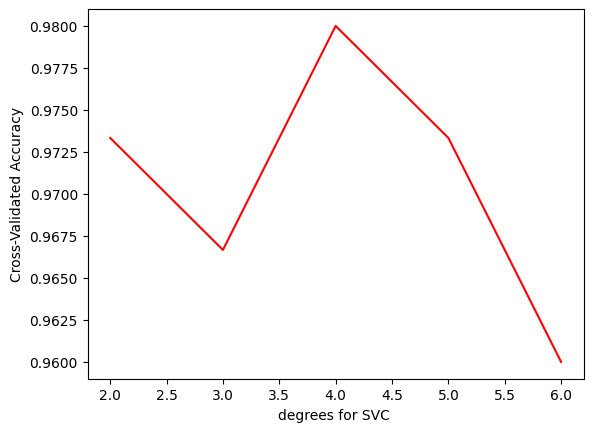

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

degree=[2,3,4,5,6]

# plot the value of C for SVM (x-axis) versus the cross-validated accuracy (y-axis)
plt.plot(degree,acc_score,color='r')
plt.xlabel('degrees for SVC ')
plt.ylabel('Cross-Validated Accuracy')

**Score is high for third degree polynomial and then there is drop in the accuracy score as degree of polynomial increases.Thus increase in polynomial degree results in high complexity of the model and thus causes overfitting.**

# Now performing SVM by taking hyperparameter C=0.1 and kernel as linear


----------

In [21]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.svm import SVC

# Example: if X and y are already defined
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svc = SVC(kernel='linear', C=0.1)
svc.fit(X_train, y_train)
y_predict = svc.predict(X_test)

accuracy_score = metrics.accuracy_score(y_test, y_predict)
print('Accuracy:', accuracy_score)


Accuracy: 1.0


# With K-fold cross validation(where K=10)

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

svc = SVC(kernel='linear', C=0.1)
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
print(scores)


[1.         0.93333333 1.         1.         1.         0.93333333
 0.93333333 0.93333333 1.         1.        ]


Taking the mean of all the scores

In [ ]:
print(scores.mean())

The accuracy is slightly good without K-fold cross validation but it may fail to generalise the unseen data.Hence it is advisable to perform K-fold cross validation where all the data is covered so it may predict unseen data well.

# Now performing SVM by taking hyperparameter gamma=0.01 and kernel as rbf

In [24]:
from sklearn.svm import SVC
svc= SVC(kernel='rbf',gamma=0.01)
svc.fit(X_train,y_train)
y_predict=svc.predict(X_test)
metrics.accuracy_score(y_test,y_predict)

0.9666666666666667

# With K-fold cross validation(where K=10)

In [25]:
svc=SVC(kernel='linear',gamma=0.01)
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
print(scores)
print(scores.mean())

[1.         0.93333333 1.         1.         0.86666667 1.
 0.93333333 1.         1.         1.        ]
0.9733333333333334


# Now performing SVM by taking hyperparameter degree=3 and kernel as poly

In [26]:
from sklearn.svm import SVC
svc= SVC(kernel='poly',degree=3)
svc.fit(X_train,y_train)
y_predict=svc.predict(X_test)
accuracy_score= metrics.accuracy_score(y_test,y_predict)
print(accuracy_score)

1.0


# With K-fold cross validation(where K=10)

In [27]:
svc=SVC(kernel='poly',degree=3)
scores = cross_val_score(svc, X, y, cv=10, scoring='accuracy')
print(scores)
print(scores.mean())

[1.         0.93333333 1.         1.         0.86666667 0.93333333
 0.93333333 1.         1.         1.        ]
0.9666666666666668


#Let us perform Grid search technique to find the best parameter

In [28]:
from sklearn.svm import SVC
svm_model= SVC()

In [29]:
tuned_parameters = {
 'C': (np.arange(0.1,1,0.1)) , 'kernel': ['linear'],
 'C': (np.arange(0.1,1,0.1)) , 'gamma': [0.01,0.02,0.03,0.04,0.05], 'kernel': ['rbf'],
 'degree': [2,3,4] ,'gamma':[0.01,0.02,0.03,0.04,0.05], 'C':(np.arange(0.1,1,0.1)) , 'kernel':['poly']
                   }

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Example: Define the SVM model
svm_model = SVC()

# Define the parameter grid to search over
tuned_parameters = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter values
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']  # Different SVM kernels
}

# Set up the GridSearchCV with 10-fold cross-validation
model_svm = GridSearchCV(svm_model, tuned_parameters, cv=10, scoring='accuracy')

# Fit the model with training data (X_train, y_train)
model_svm.fit(X_train, y_train)

# Print the best parameters and score from the grid search
print("Best parameters:", model_svm.best_params_)
print("Best cross-validation score:", model_svm.best_score_)


Best parameters: {'C': 0.1, 'kernel': 'linear'}
Best cross-validation score: 0.9583333333333334


In [32]:
model_svm.fit(X_train, y_train)
print(model_svm.best_score_)

0.9583333333333334


In [33]:
#print(model_svm.grid_scores_)

In [34]:
print(model_svm.best_params_)

{'C': 0.1, 'kernel': 'linear'}


In [35]:
y_pred= model_svm.predict(X_test)
print(metrics.accuracy_score(y_pred,y_test))

1.0


You can find my notebook on Github:
("https://github.com/nirajvermafcb/Data-Science-with-python")